# **Machine Learning Model Development**

Our preprocessed dataset conntains:

837 features

147 subjects

3 classes (HC, PD, DD)

This is called a high-dimensional, low-sample-size dataset.

What happened when we used all 837 features:

i. Many features are correlated or noisy

ii. The model overfits to random fluctuations

iii. Linear models struggle

iv. Tree models (RF, XGB) become unstable

v. Distance-based models (KNN) perform terribly

This is the classic curse of dimensionality.

With 837 features, the model needs hundreds or thousands of subjects- but we only have 147.

So reducing the number of features may reduce noise, increase signal, and prevent overfitting, giving higher test accuracy.

How many features should we keep?

From our previous work:

We already identified 164 statistically significant features using
Kruskal–Wallis → Mann–Whitney → FDR → Cliff’s delta.

Those 164 features are much cleaner and more meaningful than the full 837.

But even 164 may still be too many depending on the model.

Best features ranges for best accuracy:

i. Logistic Regression: 15-50

ii. SVM: 20-60

iii. KNN: <30

iv. Random Forest: 50-200

v. XGBoost: 30-200

The model can easily “memorize” the training data- but it cannot generalize.

When we reduce features:

i. We remove noise

ii. We remove redundant variables

iii. We force the model to learn true patterns

iv. We reduce overfitting

Thus, the model’s test performance improves.

Reducing our features is one of the most important ways to increase accuracy.

With 837 features and 147 subjects, our test accuracy will be poor due to overfitting.

Using our statistically selected 164 features and even further selecting the top 30–50 will significantly improve model performance.

# **About Dataset**

**Target**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
Target Variables
Diagnosis label: label
'''

'\nTarget Variables \nDiagnosis label: label\n'

In [ ]:
'''
This is what all our ML models (RF, SVM, etc.) are trying to predict.
label = diagnosis class:
0 = Healthy control (HC)
1 = Parkinson’s disease (PD)
2 = Other movement disorder (DD)
'''

'\nThis is what all our ML models (RF, SVM, etc.) are trying to predict.\nlabel = diagnosis class:\n0 = Healthy control (HC)\n1 = Parkinson’s disease (PD)\n2 = Other movement disorder (DD)\n'

**Input**

In [ ]:
'''
Input Variables (837)
Movement tasks: 11
left and right wrists: 2
Accelerometer and Gyroscope sensors: 2
X,Y,Z axis: 3
'''

'\nInput Variables (837)\nMovement tasks: 11\nleft and right wrists: 2\nAccelerometer and Gyroscope sensors: 2\nX,Y,Z axis: 3\n'

**Features**

In [ ]:
'''
Feature types:
SMA = signal magnitude area (combined X, Y, Z; no axis in name)
Mean = average value of the signal,
RMS = root mean square (overall intensity),
STD = standard deviation (variability),
ZCR = zero-crossing rate (how often the signal crosses zero → oscillations / tremor),
jerk_mean = mean of jerk (derivative of accel; how quickly acceleration changes),
jerk_rms = rms of jerk (intensity of acceleration changes)
'''

'\nFeature types: \nSMA = signal magnitude area (combined X, Y, Z; no axis in name)\nMean = average value of the signal, \nRMS = root mean square (overall intensity), \nSTD = standard deviation (variability), \nZCR = zero-crossing rate (how often the signal crosses zero → oscillations / tremor), \njerk_mean = mean of jerk (derivative of accel; how quickly acceleration changes), \njerk_rms = rms of jerk (intensity of acceleration changes)\n'

**Movement**

In [ ]:
'''
CrossArms = A motor task where the patient crosses both arms over the chest.
DrinkGlas = Simulated drinking motion: the patient picks up a cup or glass and brings it to their mouth.
Entrainment (stomping with arms lifted) = The patient stomps rhythmically (usually following a metronome) while lifting their arms.
HoldWeight = Patient holds a weight (light dumbbell or similar) steadily in front of the body.
LiftHold = Lifting an object or arm into a position and holding it still.
PointFinger = Patient extends the index finger and points to a target.
Relaxed = Patient remains still in a relaxed sitting or standing posture.
RelaxedTask = A relaxed posture with a mild imposed activity (e.g., light verbal task or minimal movement).
StretchHold = Patient stretches an arm or leg (e.g., fully extended) and holds the position.
TouchIndex = Touching the index fingers together or touching the index finger to a target.
TouchNose = Finger-to-nose test: patient alternates between touching their nose and an external target.
'''

'\nCrossArms = A motor task where the patient crosses both arms over the chest.\nDrinkGlas = Simulated drinking motion: the patient picks up a cup or glass and brings it to their mouth.\nEntrainment (stomping with arms lifted) = The patient stomps rhythmically (usually following a metronome) while lifting their arms.\nHoldWeight = Patient holds a weight (light dumbbell or similar) steadily in front of the body.\nLiftHold = Lifting an object or arm into a position and holding it still.\nPointFinger = Patient extends the index finger and points to a target.\nRelaxed = Patient remains still in a relaxed sitting or standing posture.\nRelaxedTask = A relaxed posture with a mild imposed activity (e.g., light verbal task or minimal movement).\nStretchHold = Patient stretches an arm or leg (e.g., fully extended) and holds the position.\nTouchIndex = Touching the index fingers together or touching the index finger to a target.\nTouchNose = Finger-to-nose test: patient alternates between touchin

**Wrist**

In [ ]:
'''
LeftWrist = Refers specifically to the left wrist joint or a sensor placed on the left wrist.
RightWrist = Refers specifically to the right wrist joint or a sensor placed on the right wrist.
'''

'\nLeftWrist = Refers specifically to the left wrist joint or a sensor placed on the left wrist.\nRightWrist = Refers specifically to the right wrist joint or a sensor placed on the right wrist.\n'

**Sensor**

In [ ]:
'''
Accelerometer (Linear Acceleration in g):
An accelerometer measures linear acceleration of a body segment (e.g., wrist, hand, foot, trunk).

Gyroscope (Angular Velocity in rad/s):
A gyroscope measures angular velocity, i.e., how fast a segment rotates. Output is expressed in radians per second (rad/s).
'''

'\nAccelerometer (Linear Acceleration in g): \nAn accelerometer measures linear acceleration of a body segment (e.g., wrist, hand, foot, trunk).\n\nGyroscope (Angular Velocity in rad/s): \nA gyroscope measures angular velocity, i.e., how fast a segment rotates. Output is expressed in radians per second (rad/s).\n'

# **Load the data**

In [2]:
import numpy as np #fundamental library for numerical computing in Python
import pandas as pd # data manipulation and analysis
train = pd.read_csv("/content/drive/MyDrive/Dataset/PD/train_full_features.csv")
test = pd.read_csv("/content/drive/MyDrive/Dataset/PD/test_full_features.csv")
train

,label,SMA_CrossArms_LeftWrist_Accelerometer,mean_CrossArms_LeftWrist_Accelerometer_X,rms_CrossArms_LeftWrist_Accelerometer_X,std_CrossArms_LeftWrist_Accelerometer_X,zcr_CrossArms_LeftWrist_Accelerometer_X,jerk_mean_CrossArms_LeftWrist_Accelerometer_X,jerk_rms_CrossArms_LeftWrist_Accelerometer_X,mean_CrossArms_LeftWrist_Accelerometer_Y,rms_CrossArms_LeftWrist_Accelerometer_Y,...,std_TouchNose_RightWrist_Gyroscope_Y,zcr_TouchNose_RightWrist_Gyroscope_Y,jerk_mean_TouchNose_RightWrist_Gyroscope_Y,jerk_rms_TouchNose_RightWrist_Gyroscope_Y,mean_TouchNose_RightWrist_Gyroscope_Z,rms_TouchNose_RightWrist_Gyroscope_Z,std_TouchNose_RightWrist_Gyroscope_Z,zcr_TouchNose_RightWrist_Gyroscope_Z,jerk_mean_TouchNose_RightWrist_Gyroscope_Z,jerk_rms_TouchNose_RightWrist_Gyroscope_Z
0,0,30.242329,0.003741,0.035257,0.035078,0.142699,-0.000218,0.003619,-0.001437,0.024154,...,2.079560,0.037611,0.001554,0.289388,0.086058,3.363210,3.363970,0.023230,0.011177,0.261312
1,0,50.893255,-0.000487,0.055418,0.055447,0.054204,-0.000592,0.005041,-0.011804,0.035709,...,1.303355,0.028761,0.001503,0.151289,0.146788,2.625071,2.622415,0.016593,0.004281,0.152973
2,0,28.991082,0.002129,0.013857,0.013700,0.190265,-0.000127,0.004746,0.001027,0.026927,...,1.152224,0.030973,-0.001157,0.150720,-0.129101,2.895691,2.894412,0.022124,-0.004773,0.161175
3,0,63.256888,0.029546,0.074465,0.068391,0.074115,-0.000101,0.006263,0.008058,0.053523,...,0.963085,0.030973,0.000223,0.108954,-0.045108,3.611756,3.613474,0.015487,0.001700,0.207159
4,0,62.759790,0.012699,0.052252,0.050714,0.140487,-0.000012,0.004122,-0.033147,0.109785,...,1.374736,0.024336,-0.000229,0.152590,-0.068134,2.440994,2.441393,0.012168,-0.004407,0.152863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0,12.838994,-0.000055,0.004825,0.004827,0.204646,-0.000005,0.003178,0.001497,0.007288,...,2.475070,0.026549,0.000685,0.368769,0.002558,0.486909,0.487172,0.088496,0.000218,0.291168
183,0,15.993868,-0.002260,0.006188,0.005764,0.153761,0.000006,0.002954,0.000717,0.009634,...,1.746091,0.037611,-0.000607,0.137656,-0.100843,1.250903,1.247522,0.055310,0.000625,0.125021
184,1,54.219908,0.011215,0.032854,0.030898,0.141593,0.000029,0.005134,-0.018936,0.034980,...,1.639577,0.018805,0.002836,0.070553,-0.071058,1.512305,1.511471,0.022124,-0.001875,0.073683
185,2,130.532591,0.027546,0.085468,0.080952,0.064159,0.000055,0.010245,0.008178,0.066555,...,0.752497,0.058628,0.000204,0.079569,0.208711,1.694779,1.682810,0.050885,-0.000071,0.086536


**Features Reduction**

**Cliff’s Delta effect-size filtering**

In [3]:
#Cliff's delta filtering (|δ| > 0.3) for PD vs HC and PD vs DD
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu


# Load our tabular feature file
df = pd.read_csv('/content/drive/MyDrive/Dataset/PD/train_full_features.csv')
# Load our dataset. Must include: 0 = HC, 1 = PD, 2 = DD

target_col = 'label'   # Name of the class label column


# Setup
features = [c for c in df.columns if c != target_col]
# All columns except the label column

X = df[features]         # Feature matrix
y = df[target_col]       # Class labels


# Split data into three groups
HC = X[y == 0]           # Healthy Controls
PD = X[y == 1]           # Parkinson's Disease
DD = X[y == 2]           # Differential Disorders


def cliffs_delta_from_u(u, n1, n2):
    """
    Convert Mann–Whitney U into Cliff's delta.
    Formula (rank-biserial correlation):
        δ = 2U / (n1 * n2) - 1
    where:
        u  = U statistic from Mann–Whitney
        n1 = sample size of group1
        n2 = sample size of group2
    """
    return (2.0 * u) / (n1 * n2) - 1.0

rows = []   # to store results for each feature

for col in features:

    # Drop missing values for this specific feature
    a_pd = PD[col].dropna().values
    b_hc = HC[col].dropna().values
    c_dd = DD[col].dropna().values

    # Skip feature if any group is empty
    if len(a_pd) == 0 or len(b_hc) == 0 or len(c_dd) == 0:
        rows.append({
            'feature': col,
            'delta_PD_vs_HC': np.nan, 'abs_delta_PD_vs_HC': np.nan,
            'delta_PD_vs_DD': np.nan, 'abs_delta_PD_vs_DD': np.nan
        })
        continue

    # Mann–Whitney U for PD vs HC
    u1, p1 = mannwhitneyu(a_pd, b_hc, alternative='two-sided')
    d1 = cliffs_delta_from_u(u1, len(a_pd), len(b_hc))   # convert to Cliff's delta

    # Mann–Whitney U for PD vs DD
    u2, p2 = mannwhitneyu(a_pd, c_dd, alternative='two-sided')
    d2 = cliffs_delta_from_u(u2, len(a_pd), len(c_dd))

    # Save results for this feature
    rows.append({
        'feature': col,
        'delta_PD_vs_HC': d1,
        'abs_delta_PD_vs_HC': abs(d1),
        'delta_PD_vs_DD': d2,
        'abs_delta_PD_vs_DD': abs(d2)
    })


# Convert to DataFrame
effect_df = pd.DataFrame(rows)


# Filter by effect size threshold
MODERATE_THRESHOLD = 0.30
# |δ| > 0.3 is a moderate effect (meaningful difference)

# Keep features where PD differs from HC OR DD
keep_mask = (effect_df['abs_delta_PD_vs_HC'] > MODERATE_THRESHOLD) | \
            (effect_df['abs_delta_PD_vs_DD'] > MODERATE_THRESHOLD)

effect_keep = effect_df.loc[keep_mask].sort_values(
    ['abs_delta_PD_vs_HC', 'abs_delta_PD_vs_DD'],
    ascending=False
).reset_index(drop=True)

print(f"Features with |δ| > {MODERATE_THRESHOLD} in PD vs (HC or DD): {len(effect_keep)}")
display(effect_keep.head(20))

try:
    # Intersection: features that have both significant p-value AND large effect size
    final_selected = effect_keep.merge(significant_posthoc[['feature']], on='feature', how='inner')

    print(f"After intersecting with Mann–Whitney p<0.05 list: {len(final_selected)} features")
    display(final_selected.head(20))

    # Save combined filtered set
    final_selected.to_csv('/content/final_selected_features_effectsize_p05.csv', index=False)

except NameError:
    # If no p<0.05 list exists, save only effect-size filtered features
    effect_keep.to_csv('/content/effectsize_features_absdelta_gt_0p3.csv', index=False)

Features with |δ| > 0.3 in PD vs (HC or DD): 164


,feature,delta_PD_vs_HC,abs_delta_PD_vs_HC,delta_PD_vs_DD,abs_delta_PD_vs_DD
0,jerk_rms_StretchHold_RightWrist_Gyroscope_Y,0.553571,0.553571,-0.153846,0.153846
1,jerk_rms_StretchHold_RightWrist_Accelerometer_X,0.550866,0.550866,-0.135664,0.135664
2,SMA_StretchHold_RightWrist_Gyroscope,0.527597,0.527597,-0.158042,0.158042
3,std_StretchHold_RightWrist_Gyroscope_Y,0.492965,0.492965,-0.206061,0.206061
4,rms_StretchHold_RightWrist_Gyroscope_Y,0.491342,0.491342,-0.206061,0.206061
5,SMA_StretchHold_RightWrist_Accelerometer,0.481061,0.481061,-0.208392,0.208392
6,jerk_rms_StretchHold_RightWrist_Gyroscope_Z,0.471320,0.471320,-0.211189,0.211189
7,zcr_Relaxed_RightWrist_Gyroscope_Z,-0.471050,0.471050,0.090909,0.090909
8,std_StretchHold_RightWrist_Accelerometer_Y,0.456169,0.456169,-0.179487,0.179487
9,rms_StretchHold_RightWrist_Accelerometer_Y,0.448593,0.448593,-0.171562,0.171562


In [4]:
features=pd.read_csv('/content/effectsize_features_absdelta_gt_0p3.csv')
features

,feature,delta_PD_vs_HC,abs_delta_PD_vs_HC,delta_PD_vs_DD,abs_delta_PD_vs_DD
0,jerk_rms_StretchHold_RightWrist_Gyroscope_Y,0.553571,0.553571,-0.153846,0.153846
1,jerk_rms_StretchHold_RightWrist_Accelerometer_X,0.550866,0.550866,-0.135664,0.135664
2,SMA_StretchHold_RightWrist_Gyroscope,0.527597,0.527597,-0.158042,0.158042
3,std_StretchHold_RightWrist_Gyroscope_Y,0.492965,0.492965,-0.206061,0.206061
4,rms_StretchHold_RightWrist_Gyroscope_Y,0.491342,0.491342,-0.206061,0.206061
...,...,...,...,...,...
159,std_DrinkGlas_LeftWrist_Accelerometer_Y,-0.007576,0.007576,-0.334266,0.334266
160,rms_DrinkGlas_RightWrist_Gyroscope_X,0.006494,0.006494,-0.313287,0.313287
161,std_DrinkGlas_RightWrist_Gyroscope_X,0.005952,0.005952,-0.314219,0.314219
162,std_DrinkGlas_LeftWrist_Accelerometer_Z,0.002706,0.002706,-0.337063,0.337063


In [5]:
feature_names = features['feature'].tolist()
feature_names

['jerk_rms_StretchHold_RightWrist_Gyroscope_Y',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_X',
 'SMA_StretchHold_RightWrist_Gyroscope',
 'std_StretchHold_RightWrist_Gyroscope_Y',
 'rms_StretchHold_RightWrist_Gyroscope_Y',
 'SMA_StretchHold_RightWrist_Accelerometer',
 'jerk_rms_StretchHold_RightWrist_Gyroscope_Z',
 'zcr_Relaxed_RightWrist_Gyroscope_Z',
 'std_StretchHold_RightWrist_Accelerometer_Y',
 'rms_StretchHold_RightWrist_Accelerometer_Y',
 'std_StretchHold_RightWrist_Accelerometer_Z',
 'rms_StretchHold_RightWrist_Accelerometer_Z',
 'SMA_HoldWeight_RightWrist_Gyroscope',
 'std_StretchHold_RightWrist_Gyroscope_Z',
 'std_HoldWeight_RightWrist_Gyroscope_Y',
 'std_StretchHold_RightWrist_Accelerometer_X',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_Z',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Accelerometer_Y',
 'rms_HoldWeight_RightWrist_Gyroscope_Y',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_X',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_X',
 'r

In [6]:
len(feature_names)

164

In [7]:
selected_features = [ 'label',
    'jerk_rms_StretchHold_RightWrist_Gyroscope_Y',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_X',
 'SMA_StretchHold_RightWrist_Gyroscope',
 'std_StretchHold_RightWrist_Gyroscope_Y',
 'rms_StretchHold_RightWrist_Gyroscope_Y',
 'SMA_StretchHold_RightWrist_Accelerometer',
 'jerk_rms_StretchHold_RightWrist_Gyroscope_Z',
 'zcr_Relaxed_RightWrist_Gyroscope_Z',
 'std_StretchHold_RightWrist_Accelerometer_Y',
 'rms_StretchHold_RightWrist_Accelerometer_Y',
 'std_StretchHold_RightWrist_Accelerometer_Z',
 'rms_StretchHold_RightWrist_Accelerometer_Z',
 'SMA_HoldWeight_RightWrist_Gyroscope',
 'std_StretchHold_RightWrist_Gyroscope_Z',
 'std_HoldWeight_RightWrist_Gyroscope_Y',
 'std_StretchHold_RightWrist_Accelerometer_X',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_Z',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Accelerometer_Y',
 'rms_HoldWeight_RightWrist_Gyroscope_Y',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_X',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_X',
 'rms_StretchHold_RightWrist_Gyroscope_Z',
 'SMA_StretchHold_LeftWrist_Gyroscope',
 'jerk_rms_HoldWeight_RightWrist_Gyroscope_X',
 'std_HoldWeight_RightWrist_Gyroscope_X',
 'zcr_DrinkGlas_RightWrist_Accelerometer_X',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_X',
 'rms_HoldWeight_RightWrist_Gyroscope_X',
 'jerk_rms_HoldWeight_RightWrist_Gyroscope_Y',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_Y',
 'jerk_rms_CrossArms_RightWrist_Accelerometer_X',
 'SMA_StretchHold_LeftWrist_Accelerometer',
 'SMA_CrossArms_RightWrist_Gyroscope',
 'std_StretchHold_RightWrist_Gyroscope_X',
 'jerk_rms_CrossArms_RightWrist_Accelerometer_Y',
 'std_CrossArms_LeftWrist_Gyroscope_X',
 'rms_CrossArms_LeftWrist_Gyroscope_X',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_Y',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Z',
 'rms_StretchHold_RightWrist_Gyroscope_X',
 'zcr_LiftHold_LeftWrist_Accelerometer_X',
 'jerk_rms_CrossArms_RightWrist_Accelerometer_Z',
 'rms_StretchHold_LeftWrist_Accelerometer_Y',
 'SMA_CrossArms_LeftWrist_Gyroscope',
 'jerk_rms_StretchHold_RightWrist_Gyroscope_X',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_X',
 'std_HoldWeight_RightWrist_Accelerometer_X',
 'jerk_rms_CrossArms_LeftWrist_Accelerometer_X',
 'jerk_rms_LiftHold_RightWrist_Accelerometer_X',
 'rms_StretchHold_LeftWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Gyroscope_Z',
 'rms_StretchHold_LeftWrist_Gyroscope_Z',
 'jerk_rms_HoldWeight_RightWrist_Gyroscope_Z',
 'SMA_CrossArms_RightWrist_Accelerometer',
 'std_StretchHold_LeftWrist_Gyroscope_Y',
 'jerk_rms_LiftHold_RightWrist_Accelerometer_Z',
 'std_StretchHold_LeftWrist_Accelerometer_X',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_Z',
 'jerk_rms_CrossArms_LeftWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_RightWrist_Gyroscope_Y',
 'jerk_rms_CrossArms_LeftWrist_Accelerometer_Y',
 'std_CrossArms_RightWrist_Gyroscope_X',
 'rms_StretchHold_RightWrist_Accelerometer_X',
 'rms_CrossArms_RightWrist_Gyroscope_X',
 'rms_HoldWeight_RightWrist_Accelerometer_X',
 'zcr_CrossArms_LeftWrist_Gyroscope_X',
 'zcr_DrinkGlas_RightWrist_Accelerometer_Y',
 'std_CrossArms_RightWrist_Accelerometer_Y',
 'zcr_CrossArms_RightWrist_Accelerometer_Z',
 'zcr_CrossArms_RightWrist_Accelerometer_Y',
 'rms_StretchHold_LeftWrist_Gyroscope_X',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_Y',
 'std_PointFinger_RightWrist_Accelerometer_Z',
 'std_StretchHold_LeftWrist_Gyroscope_X',
 'rms_PointFinger_LeftWrist_Gyroscope_Z',
 'zcr_LiftHold_RightWrist_Accelerometer_X',
 'rms_PointFinger_RightWrist_Accelerometer_Z',
 'std_PointFinger_LeftWrist_Gyroscope_Z',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_Y',
 'rms_CrossArms_RightWrist_Accelerometer_Y',
 'rms_StretchHold_LeftWrist_Accelerometer_X',
 'jerk_rms_HoldWeight_RightWrist_Accelerometer_X',
 'SMA_HoldWeight_RightWrist_Accelerometer',
 'rms_DrinkGlas_RightWrist_Gyroscope_Z',
 'zcr_HoldWeight_RightWrist_Accelerometer_X',
 'std_DrinkGlas_RightWrist_Gyroscope_Z',
 'mean_PointFinger_RightWrist_Gyroscope_X',
 'std_HoldWeight_RightWrist_Accelerometer_Z',
 'jerk_rms_LiftHold_RightWrist_Gyroscope_Y',
 'jerk_rms_PointFinger_LeftWrist_Gyroscope_Z',
 'std_TouchNose_RightWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Accelerometer_Z',
 'SMA_CrossArms_LeftWrist_Accelerometer',
 'rms_TouchNose_RightWrist_Gyroscope_Y',
 'rms_PointFinger_LeftWrist_Accelerometer_X',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_Z',
 'rms_TouchNose_LeftWrist_Gyroscope_Y',
 'std_TouchNose_LeftWrist_Gyroscope_Y',
 'mean_CrossArms_RightWrist_Gyroscope_Z',
 'std_PointFinger_LeftWrist_Accelerometer_X',
 'std_PointFinger_LeftWrist_Accelerometer_Y',
 'rms_HoldWeight_RightWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_RightWrist_Gyroscope_Z',
 'rms_StretchHold_LeftWrist_Accelerometer_Z',
 'rms_PointFinger_LeftWrist_Accelerometer_Y',
 'zcr_CrossArms_LeftWrist_Gyroscope_Z',
 'jerk_rms_LiftHold_LeftWrist_Accelerometer_X',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_Z',
 'rms_Relaxed_RightWrist_Gyroscope_Z',
 'SMA_LiftHold_RightWrist_Gyroscope',
 'zcr_StretchHold_RightWrist_Gyroscope_X',
 'std_Relaxed_RightWrist_Gyroscope_Z',
 'jerk_rms_HoldWeight_RightWrist_Accelerometer_Y',
 'std_HoldWeight_RightWrist_Accelerometer_Y',
 'zcr_CrossArms_LeftWrist_Accelerometer_Y',
 'zcr_Entrainment_RightWrist_Accelerometer_Z',
 'SMA_LiftHold_RightWrist_Accelerometer',
 'mean_Relaxed_RightWrist_Accelerometer_Y',
 'SMA_HoldWeight_LeftWrist_Gyroscope',
 'jerk_rms_LiftHold_LeftWrist_Gyroscope_Z',
 'rms_DrinkGlas_RightWrist_Accelerometer_X',
 'SMA_DrinkGlas_LeftWrist_Gyroscope',
 'std_LiftHold_LeftWrist_Accelerometer_Y',
 'jerk_rms_RelaxedTask_LeftWrist_Accelerometer_Y',
 'jerk_rms_DrinkGlas_LeftWrist_Gyroscope_X',
 'std_DrinkGlas_RightWrist_Accelerometer_X',
 'rms_LiftHold_LeftWrist_Accelerometer_Y',
 'SMA_LiftHold_LeftWrist_Accelerometer',
 'jerk_rms_HoldWeight_LeftWrist_Gyroscope_Y',
 'rms_RelaxedTask_LeftWrist_Accelerometer_Y',
 'jerk_rms_RelaxedTask_LeftWrist_Gyroscope_Z',
 'std_RelaxedTask_LeftWrist_Accelerometer_Y',
 'jerk_rms_DrinkGlas_RightWrist_Gyroscope_X',
 'zcr_RelaxedTask_RightWrist_Accelerometer_X',
 'rms_DrinkGlas_RightWrist_Accelerometer_Y',
 'mean_CrossArms_LeftWrist_Gyroscope_Y',
 'jerk_rms_TouchIndex_RightWrist_Accelerometer_Y',
 'std_DrinkGlas_LeftWrist_Gyroscope_X',
 'SMA_DrinkGlas_RightWrist_Gyroscope',
 'rms_LiftHold_LeftWrist_Accelerometer_X',
 'jerk_rms_TouchIndex_LeftWrist_Gyroscope_Y',
 'jerk_rms_RelaxedTask_LeftWrist_Gyroscope_X',
 'SMA_RelaxedTask_LeftWrist_Accelerometer',
 'SMA_DrinkGlas_RightWrist_Accelerometer',
 'std_DrinkGlas_RightWrist_Accelerometer_Y',
 'rms_DrinkGlas_LeftWrist_Accelerometer_X',
 'rms_DrinkGlas_RightWrist_Accelerometer_Z',
 'jerk_rms_TouchIndex_RightWrist_Gyroscope_Y',
 'std_DrinkGlas_LeftWrist_Accelerometer_X',
 'zcr_DrinkGlas_RightWrist_Gyroscope_X',
 'jerk_rms_DrinkGlas_RightWrist_Gyroscope_Z',
 'std_DrinkGlas_RightWrist_Accelerometer_Z',
 'std_LiftHold_LeftWrist_Accelerometer_X',
 'jerk_rms_DrinkGlas_RightWrist_Accelerometer_Y',
 'rms_DrinkGlas_LeftWrist_Accelerometer_Y',
 'jerk_rms_TouchIndex_RightWrist_Accelerometer_Z',
 'SMA_DrinkGlas_LeftWrist_Accelerometer',
 'jerk_rms_DrinkGlas_LeftWrist_Gyroscope_Z',
 'std_DrinkGlas_LeftWrist_Accelerometer_Y',
 'rms_DrinkGlas_RightWrist_Gyroscope_X',
 'std_DrinkGlas_RightWrist_Gyroscope_X',
 'std_DrinkGlas_LeftWrist_Accelerometer_Z',
 'rms_DrinkGlas_LeftWrist_Accelerometer_Z'
]
print("Number of selected features:", len(selected_features))

train = train[selected_features]
test  = test[selected_features]

print("Train (selected) shape:", train.shape)
print("Test (selected) shape: ", test.shape)


Number of selected features: 165
Train (selected) shape: (187, 165)
Test (selected) shape:  (47, 165)


In [8]:
train

,label,jerk_rms_StretchHold_RightWrist_Gyroscope_Y,jerk_rms_StretchHold_RightWrist_Accelerometer_X,SMA_StretchHold_RightWrist_Gyroscope,std_StretchHold_RightWrist_Gyroscope_Y,rms_StretchHold_RightWrist_Gyroscope_Y,SMA_StretchHold_RightWrist_Accelerometer,jerk_rms_StretchHold_RightWrist_Gyroscope_Z,zcr_Relaxed_RightWrist_Gyroscope_Z,std_StretchHold_RightWrist_Accelerometer_Y,...,jerk_rms_DrinkGlas_RightWrist_Accelerometer_Y,rms_DrinkGlas_LeftWrist_Accelerometer_Y,jerk_rms_TouchIndex_RightWrist_Accelerometer_Z,SMA_DrinkGlas_LeftWrist_Accelerometer,jerk_rms_DrinkGlas_LeftWrist_Gyroscope_Z,std_DrinkGlas_LeftWrist_Accelerometer_Y,rms_DrinkGlas_RightWrist_Gyroscope_X,std_DrinkGlas_RightWrist_Gyroscope_X,std_DrinkGlas_LeftWrist_Accelerometer_Z,rms_DrinkGlas_LeftWrist_Accelerometer_Z
0,0,0.005213,0.002157,33.398851,0.011741,0.012001,10.589299,0.003876,0.132743,0.006352,...,0.023638,0.064297,0.049864,91.521105,0.030256,0.063915,0.648959,0.644895,0.057597,0.058130
1,0,0.003337,0.001776,18.203171,0.008412,0.008481,6.896499,0.002450,0.212389,0.002997,...,0.027135,0.123760,0.040899,170.191976,0.067973,0.123456,0.871281,0.859043,0.086166,0.087944
2,0,0.007921,0.004875,36.207710,0.015026,0.015070,13.246734,0.006506,0.228982,0.007955,...,0.081169,0.220460,0.030395,211.470567,0.126444,0.219995,0.634594,0.633604,0.150800,0.151841
3,0,0.003844,0.002394,36.981255,0.013873,0.014160,12.084112,0.004389,0.178097,0.006904,...,0.027091,0.080563,0.003417,118.144533,0.040730,0.078614,0.591316,0.586662,0.060582,0.062241
4,0,0.004258,0.002330,24.150177,0.012124,0.012771,9.371164,0.003793,0.146018,0.004189,...,0.050177,0.103222,0.043243,139.459597,0.044493,0.103202,0.767814,0.754918,0.069009,0.072512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0,0.004344,0.002134,28.133816,0.012201,0.012349,9.784816,0.004211,0.211283,0.004872,...,0.008982,0.026602,0.014386,41.086959,0.041167,0.023502,0.270265,0.269746,0.013397,0.015028
183,0,0.008567,0.003300,54.338173,0.018466,0.018607,16.311201,0.007200,0.068584,0.009976,...,0.011902,0.030958,0.012695,46.297277,0.011547,0.024305,0.236398,0.234790,0.016832,0.016925
184,1,0.006828,0.003960,46.753929,0.020477,0.020470,16.542310,0.005494,0.105088,0.008975,...,0.020252,0.077791,0.017908,91.103626,0.076650,0.077051,0.598831,0.593042,0.041743,0.042440
185,2,0.006762,0.002923,46.192930,0.024800,0.024826,18.710630,0.005033,0.146018,0.008167,...,0.029213,0.074601,0.045664,123.876708,0.048336,0.073826,0.616027,0.616101,0.061087,0.061370


# **Machine Learning Algorithms**

**Logistic Regression**

In [9]:
import pandas as pd
# pandas is used for loading CSV files and handling data tables (DataFrames)

from sklearn.pipeline import Pipeline
# Pipeline allows chaining preprocessing steps (like scaling) with a model in one unified workflow

from sklearn.preprocessing import StandardScaler
# StandardScaler standardizes features by removing the mean and scaling to unit variance
# Logistic Regression performs MUCH better when features are standardized

from sklearn.linear_model import LogisticRegression
# LogisticRegression is the classification algorithm we are using
# Works well for binary or multiclass tasks and produces interpretable models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score        → evaluates overall accuracy
# classification_report → prints precision, recall, F1-score for each class
# confusion_matrix      → shows prediction errors and class-by-class counts

In [10]:
# 1. Load train and test
#Already done

# Adjust the column name for our target variable:
TARGET = "label"

# Split the training data into: features (X) and labels (y)
X_train = train.drop(columns=[TARGET]) #separate input variables for training
y_train = train[TARGET] #separate target or output variable for training

# Split the test data
X_test = test.drop(columns=[TARGET]) #separate input variables for testing
y_test = test[TARGET] #separate target or output variable for testing


In [ ]:
# 2. Logistic Regression pipeline

logreg = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    # StandardScaler transforms each feature to have mean=0 and std=1.
    # with_mean=False is required when data might be sparse (avoids errors).

    ("clf", LogisticRegression(
        max_iter=2000,          # Allow many iterations to ensure LR converges
        class_weight="balanced",# Adjusts class weights according to label frequency (helps with imbalance)
        solver="lbfgs",         # Optimization algorithm (fast, stable, supports multinomial)
        multi_class="auto",     # Automatically choose binary or multinomial LR
        random_state=42         # Ensures reproducible results
    ))
])


# 3. Train

logreg.fit(X_train, y_train)                    # Fit the scaler + logistic regression model on training data

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    multi_class='auto', random_state=42))])

In [ ]:
# 4. Predict

y_pred = logreg.predict(X_test)                 # Use the trained model to predict labels for test data


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))  # Compute overall accuracy

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))                       # Show how predictions fall across classes

print("\nClassification Report:\n",
      classification_report(y_test, y_pred, digits=3))        # Precision, recall, F1-score per class

Accuracy: 0.532

Confusion Matrix:
 [[8 4 2]
 [4 8 5]
 [2 5 9]]

Classification Report:
               precision    recall  f1-score   support

           0      0.571     0.571     0.571        14
           1      0.471     0.471     0.471        17
           2      0.562     0.562     0.562        16

    accuracy                          0.532        47
   macro avg      0.535     0.535     0.535        47
weighted avg      0.532     0.532     0.532        47



Hyperparameter tuning

In [ ]:
# example of grid searching key hyperparametres for logistic regression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# define models and parameters
model = LogisticRegression()
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]

# define grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.528070 using {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.485283 (0.136721) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.505458 (0.122535) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.503021 (0.139970) with: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.528070 (0.143798) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.509064 (0.109012) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.519103 (0.147925) with: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.505263 (0.140852) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.500195 (0.115774) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.517739 (0.137758) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.516179 (0.122922) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.503704 (0.110823) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.507212 (0.123708) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.510624 (0.127550) with

**k-nearest neighbors**

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load train and test
#Already done

In [ ]:
# 2. KNN pipeline (scaler + model)

knn = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    # StandardScaler normalizes features.
    # KNN is distance-based → scaling is essential so no feature dominates.

    ("clf", KNeighborsClassifier(
        n_neighbors=5,          # k = 5 neighbors (common default starting point)
        weights="distance"      # Closer neighbors get more influence than farther ones
    ))
])


# 3. Train

knn.fit(X_train, y_train)                        # Fit the pipeline (scale → KNN) on training data

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf', KNeighborsClassifier(weights='distance'))])

In [ ]:
# 4. Predict

y_pred = knn.predict(X_test)                     # Use trained model to predict class labels for test data


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
# Accuracy = proportion of correct predictions

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Confusion matrix = shows TP, FP, TN, FN per class

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
# Precision, recall, F1-score for each class (3 decimal places)

Accuracy: 0.447

Confusion Matrix:
 [[5 5 4]
 [5 7 5]
 [3 4 9]]

Classification Report:
               precision    recall  f1-score   support

           0      0.385     0.357     0.370        14
           1      0.438     0.412     0.424        17
           2      0.500     0.562     0.529        16

    accuracy                          0.447        47
   macro avg      0.441     0.444     0.441        47
weighted avg      0.443     0.447     0.444        47



Hyperparameter tuning

In [ ]:
# example of grid searching key hyperparametres for KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# define models and parameters
model = KNeighborsClassifier()
n_neighbors = range(1, 21, 2)
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

# define grid search
grid = dict(n_neighbors=n_neighbors,weights=weights,metric=metric)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.587817 using {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
0.474756 (0.113744) with: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
0.474756 (0.113744) with: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'distance'}
0.492495 (0.109901) with: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
0.487037 (0.116220) with: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
0.469883 (0.112247) with: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
0.512281 (0.114246) with: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
0.495322 (0.107843) with: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
0.521832 (0.098799) with: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
0.493080 (0.112149) with: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
0.517934 (0.107234) with: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
0.505556

**Gradient Boosting**

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load train and test
# Already done

In [ ]:
# 2. Define Gradient Boosting model

gb = GradientBoostingClassifier(
    n_estimators=200,     # Number of boosting stages (200 sequential trees)
    learning_rate=0.05,   # Shrinks each tree's contribution; smaller = more stable but slower
    max_depth=3,          # Depth of individual trees (prevents overfitting)
    random_state=42       # Ensures reproducible results
)


# 3. Train

gb.fit(X_train, y_train)                         # Fit the boosting model on training data

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
# 4. Predict

y_pred = gb.predict(X_test)                      # Predict class labels for test data


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
# Accuracy = percentage of correct predictions

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Confusion matrix shows true vs predicted class counts

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
# Precision, recall, and F1-score for each class (rounded to 3 decimals)

Accuracy: 0.574

Confusion Matrix:
 [[9 4 1]
 [3 9 5]
 [1 6 9]]

Classification Report:
               precision    recall  f1-score   support

           0      0.692     0.643     0.667        14
           1      0.474     0.529     0.500        17
           2      0.600     0.562     0.581        16

    accuracy                          0.574        47
   macro avg      0.589     0.578     0.582        47
weighted avg      0.582     0.574     0.577        47



ROC–AUC (multiclass, macro): 0.741


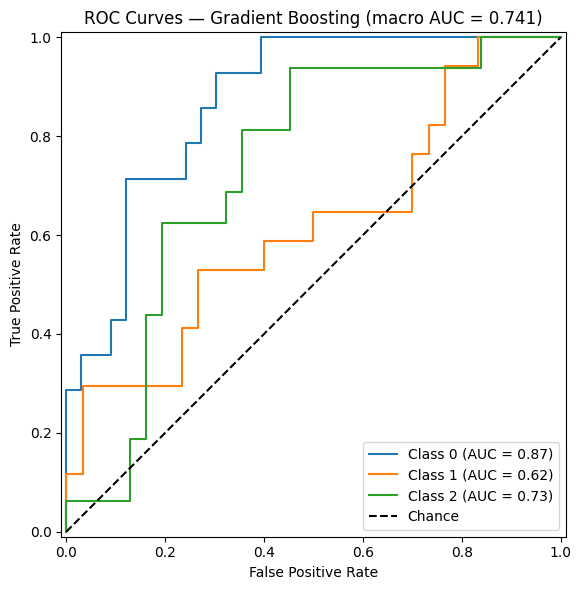

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict class probabilities for each test sample
y_prob = gb.predict_proba(X_test)     # Shape = (n_samples, n_classes)

# Get the class labels learned by the model (e.g., [0, 1] or [0, 1, 2])
classes = gb.classes_

# Number of unique classes
n_classes = len(classes)

# Case 1: Binary classification (2 classes)
if n_classes == 2:
    # AUC
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Gradient Boosting")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# Case 2: Multiclass classification (> 2 classes)
else:
    # Binarize y_test
    y_test_bin = label_binarize(y_test, classes=classes)

    # Macro-average AUC
    auc_macro = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    # One-vs-rest ROC curves per class
    plt.figure(figsize=(7, 6))
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_prob[:, i],
            name=f"Class {c}",
            ax=plt.gca()
        )

    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — Gradient Boosting (macro AUC = {auc_macro:.3f})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Predict class probabilities
y_prob = gb.predict_proba(X_test)      # shape = (n_samples, n_classes)

# Get class names from the model (e.g., [0, 1, 2])
classes = gb.classes_

# Convert to DataFrame
prob_table = pd.DataFrame(
    y_prob,
    columns=[f"Prob_Class_{c}" for c in classes]
)

# (Optional) add true label for comparison
prob_table["True_Label"] = y_test.values

# (Optional) add predicted class
prob_table["Predicted_Class"] = gb.predict(X_test)

# Show the first few rows
prob_table.head()

,Prob_Class_0,Prob_Class_1,Prob_Class_2,True_Label,Predicted_Class
0,0.854974,0.110915,0.034111,0,0
1,0.122163,0.365600,0.512237,2,2
2,0.883283,0.003929,0.112788,2,0
3,0.662455,0.245208,0.092337,0,0
4,0.028242,0.840390,0.131368,2,1


Hyperparameter tuning

In [ ]:
# example of grid searching key hyperparameters for GradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# define models and parameters
model = GradientBoostingClassifier()
n_estimators = [10, 100, 1000]
learning_rate = [0.001, 0.01, 0.1]
subsample = [0.5, 0.7, 1.0]
max_depth = [3, 7, 9]

# define grid search
grid = dict(learning_rate=learning_rate, n_estimators=n_estimators, subsample=subsample, max_depth=max_depth)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.582261 using {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.5}
0.398246 (0.086678) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 10, 'subsample': 0.5}
0.398246 (0.086678) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 10, 'subsample': 0.7}
0.392982 (0.093888) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 10, 'subsample': 1.0}
0.475634 (0.091155) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.5}
0.465010 (0.091184) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
0.436745 (0.113080) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
0.573294 (0.108914) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.5}
0.560819 (0.120420) with: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7}
0.522222 (0.119152) with: {'learning_rate': 0.001, 'm

**Random Forest**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Adjust the column name for our target variable:
#already done

In [ ]:
# Train Random Forest
'''
Creates a new Random Forest classifier object using scikit-learn.
A Random Forest is an ensemble of many decision trees that vote on the final prediction.
'''
rf = RandomForestClassifier(
    n_estimators=500,        # number of trees (More trees → more stable and accurate model, but slower.)
    max_depth=None,          # None means trees grow until all leaves are pure or contain fewer than 2 samples.
    class_weight="balanced", # handle class imbalance: Automatically adjusts weights inversely proportional to class frequencies.
    random_state=42,         # Sets a seed for reproducibility. Ensures we get the same results every time we run the code.
    n_jobs=-1                # Controls how many CPU cores to use. -1 = use all available cores for maximum speed during training.
)

rf.fit(X_train, y_train)     # Train the random forest model

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
#Evaluate on test data
y_pred = rf.predict(X_test)  # Evaluate the model

print("Accuracy:", accuracy_score(y_test, y_pred)) #Finding accuracy
print("\nClassification Report:\n", classification_report(y_test, y_pred)) #determining classification report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred)) #finding confusion matrix

Accuracy: 0.574468085106383

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.64      0.69        14
           1       0.45      0.59      0.51        17
           2       0.62      0.50      0.55        16

    accuracy                           0.57        47
   macro avg       0.61      0.58      0.59        47
weighted avg       0.60      0.57      0.58        47

Confusion Matrix:
 [[ 9  5  0]
 [ 2 10  5]
 [ 1  7  8]]


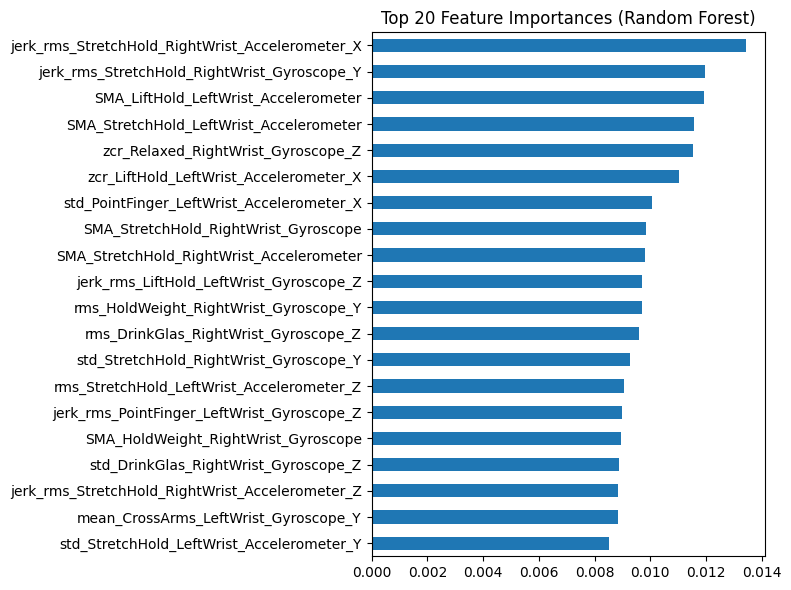

In [ ]:
#Feature importance
'''
After training, a Random Forest determines the importance of each feature in making decisions.
i. Each tree measures how much each feature reduces impurity (e.g., Gini impurity).
ii. These reductions are averaged across all trees.
iii. The final importance values are stored in:
To do that, we use rf.feature_importances_
'''

import matplotlib.pyplot as plt #plotting library used to create graphs.

'''
rf.feature_importances_
Gets an array of importance values calculated by the trained Random Forest (one value per feature).

pd.Series(...)
Converts that array into a pandas Series.

index=X_train.columns
Assigns each importance value to the correct feature name.
'''
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

#A list of the 20 most important features with their importance scores
top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top.plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ROC–AUC (multiclass, macro): 0.709
ROC–AUC (multiclass, weighted): 0.699


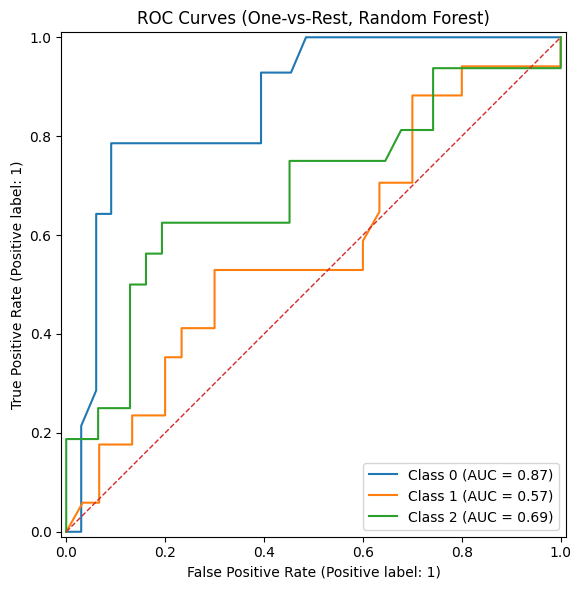

In [ ]:
# Probability outputs, ROC–AUC, and ROC plots

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# 1) Predicted class probabilities
y_prob = rf.predict_proba(X_test)   # Predict probability for each class → shape = (n_samples, n_classes)
classes = rf.classes_               # Get the class labels learned by the model
n_classes = len(classes)            # Count how many classes (binary = 2, multiclass > 2)

# 2) ROC–AUC (works for binary or multiclass)
if n_classes == 2:
    # For binary classification: use probability of the positive class (column 1)
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # Plot ROC curve using scikit-learn’s built-in visualization
    RocCurveDisplay.from_estimator(rf, X_test, y_test)
    plt.title("ROC Curve (Random Forest)")
    plt.tight_layout()
    plt.show()

else:
    # For multiclass: convert true labels into one-vs-rest binary indicators
    y_test_bin = label_binarize(y_test, classes=classes)

    # Compute One-vs-Rest macro AUC (average across all classes, treating each equally)
    auc_macro = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")

    # Weighted AUC (weights each class by its sample size)
    auc_weighted = roc_auc_score(y_test_bin, y_prob, average="weighted", multi_class="ovr")

    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")
    print(f"ROC–AUC (multiclass, weighted): {auc_weighted:.3f}")

    # Plot ROC curve for each class separately (One-vs-Rest)
    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],    # True binary label for class i
            y_prob[:, i],        # Probability of class i
            name=f"Class {cls}", # Add class name to legend
            ax=plt.gca()         # Plot on the same axes
        )

    # Add diagonal line (random guess baseline)
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.title("ROC Curves (One-vs-Rest, Random Forest)")
    plt.tight_layout()
    plt.show()

In [ ]:
# 3) Create a table of predicted probabilities
topk = 5                           # Number of rows to show
proba_df = (
    pd.DataFrame(y_prob, columns=[f"p(class={c})" for c in classes])  # Create a DataFrame with probability columns
    .assign(true=y_test.values,    # Add true label
            pred=rf.predict(X_test))  # Add predicted label
)

print("\nSample probability rows:")
display(proba_df.head(topk))       # Display first topk rows of the probability table


Sample probability rows:


,p(class=0),p(class=1),p(class=2),true,pred
0,0.384,0.394,0.222,0,1
1,0.142,0.404,0.454,2,2
2,0.310,0.418,0.272,2,1
3,0.434,0.288,0.278,0,0
4,0.208,0.440,0.352,2,1


Hyperparameter tuning

In [ ]:
# example of grid searching key hyperparameters for RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# define models and parameters
model = RandomForestClassifier()
n_estimators = [10, 100, 1000]
max_features = ['sqrt', 'log2']

# define grid search
grid = dict(n_estimators=n_estimators,max_features=max_features)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.600000 using {'max_features': 'log2', 'n_estimators': 1000}
0.554191 (0.078831) with: {'max_features': 'sqrt', 'n_estimators': 10}
0.575146 (0.115483) with: {'max_features': 'sqrt', 'n_estimators': 100}
0.593080 (0.118465) with: {'max_features': 'sqrt', 'n_estimators': 1000}
0.503996 (0.126228) with: {'max_features': 'log2', 'n_estimators': 10}
0.583918 (0.118540) with: {'max_features': 'log2', 'n_estimators': 100}
0.600000 (0.119403) with: {'max_features': 'log2', 'n_estimators': 1000}


**Support Vector Machine**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

#1) Load data
#Already done in the previous model

# Split input features (X) and target labels (y)
#Already done in the previous model

In [ ]:
# 2) SVM pipeline (scaling + RBF SVM)

svm = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    # StandardScaler scales each feature so SVM works better.
    # with_mean=False avoids errors if data is sparse.

    ("svc", SVC(kernel="rbf",                 # Use RBF kernel (default, good for nonlinear problems)
                C=10.0,                       # Regularization strength (higher = less regularization)
                gamma="scale",                # Automatic gamma setting based on feature variance
                class_weight="balanced",      # Handles imbalanced datasets by weighting classes
                probability=True,             # Enable probability prediction (for ROC–AUC)
                random_state=42))             # Ensures reproducibility
])

svm.fit(X_train, y_train)                     # Train the full pipeline (scaling + SVM)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('svc',
                 SVC(C=10.0, class_weight='balanced', probability=True,
                     random_state=42))])

In [ ]:
# 3) Evaluate model

y_pred = svm.predict(X_test)                 # Predict class labels for test data

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))  # Compute accuracy

print("\nClassification Report:\n",
      classification_report(y_test, y_pred, digits=3))          # Precision, Recall, F1-score

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred))                         # TP, FP, FN, TN counts

Accuracy: 0.511

Classification Report:
               precision    recall  f1-score   support

           0      0.533     0.571     0.552        14
           1      0.500     0.471     0.485        17
           2      0.500     0.500     0.500        16

    accuracy                          0.511        47
   macro avg      0.511     0.514     0.512        47
weighted avg      0.510     0.511     0.510        47

Confusion Matrix:
 [[8 4 2]
 [3 8 6]
 [4 4 8]]


ROC–AUC (multiclass, macro): 0.712


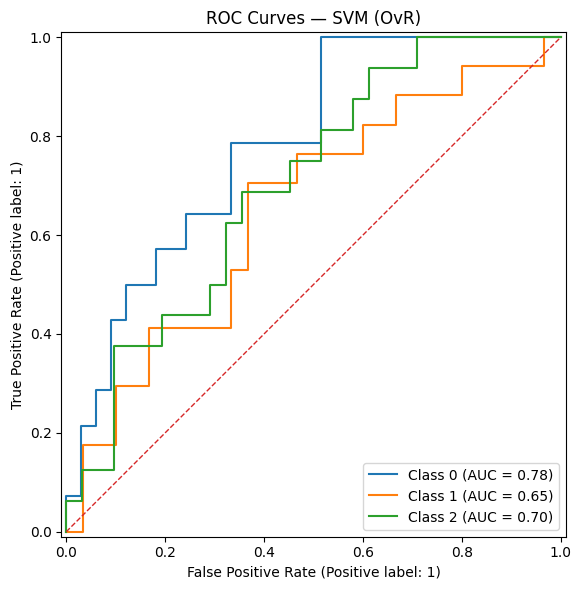

In [ ]:
# 4) ROC–AUC + ROC curves

y_prob = svm.predict_proba(X_test)           # Predict class probabilities for ROC curves
classes = svm.named_steps["svc"].classes_    # Extract ordered class labels
n_classes = len(classes)                     # Count number of classes

if n_classes == 2:
    # --- Binary classification case ---
    auc = roc_auc_score(y_test, y_prob[:, 1])   # Only probability of positive class (index 1)
    print(f"ROC–AUC (binary): {auc:.3f}")

    # Plot the ROC curve automatically
    RocCurveDisplay.from_estimator(svm, X_test, y_test)
    plt.title("ROC Curve — SVM (RBF)")
    plt.tight_layout()
    plt.show()

else:
    # --- Multiclass case (One-vs-Rest ROC) ---
    y_test_bin = label_binarize(y_test, classes=classes)   # Convert to binary indicator per class

    # Macro AUC = average AUC across classes
    auc_macro = roc_auc_score(y_test_bin, y_prob,
                              average="macro", multi_class="ovr")
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    # Plot ROC curve for each class
    plt.figure(figsize=(7, 6))
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],        # True binary label for class i
            y_prob[:, i],            # Predicted probability for class i
            name=f"Class {c}",       # Label in legend
            ax=plt.gca()             # Plot all curves on the same graph
        )

    plt.plot([0, 1], [0, 1], "--", lw=1)    # Diagonal = random guessing baseline
    plt.title("ROC Curves — SVM (OvR)")
    plt.tight_layout()
    plt.show()

In [ ]:
# 5) Probability table preview

proba_df = (
    pd.DataFrame(                         # Create DataFrame from class probabilities
        y_prob,
        columns=[f"p(class={c})" for c in classes]
    )
    .assign(true=y_test.values,           # Add true class label
            pred=y_pred)                  # Add predicted class label
)

print("\nSample probability rows:")
print(proba_df.head())                    # Show first few rows of probability table


Sample probability rows:
   p(class=0)  p(class=1)  p(class=2)  true  pred
0    0.333185    0.346489    0.320326     0     0
1    0.130595    0.484000    0.385405     2     1
2    0.255011    0.190993    0.553996     2     2
3    0.349118    0.239901    0.410981     0     2
4    0.163736    0.396135    0.440129     2     2


Hyperparameter tuning

In [ ]:
# example of grid searching key hyperparametres for SVC
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# define model and parameters
model = SVC()
kernel = ['poly', 'rbf', 'sigmoid']
C = [50, 10, 1.0, 0.1, 0.01]
gamma = ['scale']

# define grid search
grid = dict(kernel=kernel,C=C,gamma=gamma)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.523879 using {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
0.493470 (0.112337) with: {'C': 50, 'gamma': 'scale', 'kernel': 'poly'}
0.493470 (0.095314) with: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
0.319103 (0.099841) with: {'C': 50, 'gamma': 'scale', 'kernel': 'sigmoid'}
0.440643 (0.094739) with: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
0.523879 (0.115075) with: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
0.317349 (0.100029) with: {'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}
0.435478 (0.085248) with: {'C': 1.0, 'gamma': 'scale', 'kernel': 'poly'}
0.500877 (0.109770) with: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
0.364620 (0.109301) with: {'C': 1.0, 'gamma': 'scale', 'kernel': 'sigmoid'}
0.402729 (0.069181) with: {'C': 0.1, 'gamma': 'scale', 'kernel': 'poly'}
0.378850 (0.065577) with: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
0.315789 (0.035954) with: {'C': 0.1, 'gamma': 'scale', 'kernel': 'sigmoid'}
0.361793 (0.036977) with: {'C': 0.01, 'gamma': 'scale', 

**XGBoost (eXtreme Gradient Boosting)**

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load train and test
# Already done

In [ ]:
# 2. Define XGBoost model

xgb = XGBClassifier(
    n_estimators=400,           # Number of boosting trees (more trees = more power)
    learning_rate=0.05,         # Shrinks updates → slower but more stable learning
    max_depth=6,                # Maximum depth of each tree (complexity)
    subsample=0.8,              # Use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,       # Use 80% of features per tree (reduces overfitting)
    objective="multi:softprob", # Multiclass probability output (works for 2 or 3+ classes)
    eval_metric="mlogloss",     # Evaluation metric for training (multiclass log-loss)
    random_state=42,            # Ensures reproducibility
    n_jobs=-1                   # Use all CPU cores for faster training
)
# 3. Train

xgb.fit(X_train, y_train)       # Fit the XGBoost model on the training data

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# 4. Predict

y_pred = xgb.predict(X_test)    # Predict class labels for the test dataset


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
# Accuracy = proportion of correct predictions

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Confusion matrix = true vs predicted class counts

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
# Shows precision, recall, F1-score for each class (3 decimal places)

Accuracy: 0.617

Confusion Matrix:
 [[11  3  0]
 [ 2 10  5]
 [ 2  6  8]]

Classification Report:
               precision    recall  f1-score   support

           0      0.733     0.786     0.759        14
           1      0.526     0.588     0.556        17
           2      0.615     0.500     0.552        16

    accuracy                          0.617        47
   macro avg      0.625     0.625     0.622        47
weighted avg      0.618     0.617     0.615        47



ROC–AUC (multiclass, macro): 0.748


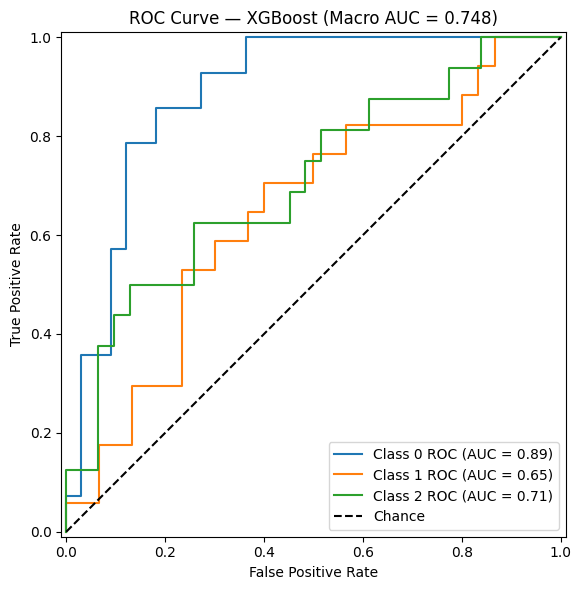

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Predict class probabilities
y_prob = xgb.predict_proba(X_test)
classes = xgb.classes_
n_classes = len(classes)

# ============================
# Case 1 – Binary ROC Curve
# ============================
if n_classes == 2:

    # Compute AUC
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — XGBoost")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# ============================
# Case 2 – Multiclass ROC Curve (One-vs-Rest)
# ============================
else:
    # Binarize true labels
    y_test_bin = label_binarize(y_test, classes=classes)

    # Compute macro AUC
    auc_macro = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    plt.figure(figsize=(7, 6))

    # Plot one ROC curve per class
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_prob[:, i],
            name=f"Class {c} ROC",
            ax=plt.gca()
        )

    # Chance diagonal
    plt.plot([0, 1], [0, 1], "k--", label="Chance")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — XGBoost (Macro AUC = {auc_macro:.3f})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Predict class probabilities for the test set
y_prob = xgb.predict_proba(X_test)          # shape = (n_samples, n_classes)

# Extract class labels learned by the model
classes = xgb.classes_

# Convert probabilities to a DataFrame
prob_table = pd.DataFrame(
    y_prob,
    columns=[f"Prob_Class_{c}" for c in classes]
)

# Add true label for comparison
prob_table["True_Label"] = y_test.values

# Add predicted class
prob_table["Predicted_Class"] = xgb.predict(X_test)

# Add row index (optional — helpful for merging)
prob_table["Sample_Index"] = prob_table.index

# Show table
prob_table.head()

,Prob_Class_0,Prob_Class_1,Prob_Class_2,True_Label,Predicted_Class,Sample_Index
0,0.793049,0.137584,0.069367,0,0,0
1,0.047777,0.255894,0.696329,2,2,1
2,0.662600,0.074765,0.262634,2,0,2
3,0.485511,0.393317,0.121172,0,0,3
4,0.071685,0.809662,0.118653,2,1,4


Hyperparameter tuning

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# define XGBoost classifier
xgb_clf = xgb.XGBClassifier()

# define hyperparameters to tune
params = {'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
          'learning_rate': [0.01, 0.05, 0.1, 0.5, 1],
          'n_estimators': [50, 100, 200, 300, 400]}

# create grid search object
grid_search = GridSearchCV(xgb_clf, param_grid=params, cv=5, n_jobs=-1)

# fit grid search object to data
grid_search.fit(X_train, y_train)

# print best hyperparameters and corresponding accuracy score
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Accuracy Score: ", grid_search.best_score_)

Best Hyperparameters:  {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400}
Best Accuracy Score:  0.5510668563300143


**AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# If you have reduced features, you can do:
# X_train_used = X_train_topK
# X_test_used  = X_test_topK
X_train_used = X_train
X_test_used  = X_test

# Weak/base learner: small decision tree
base_est = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=base_est,
    n_estimators=200,      # number of weak learners
    learning_rate=0.5,
    random_state=42
)

# Train
ada.fit(X_train_used, y_train)

# Predict
y_pred = ada.predict(X_test_used)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"AdaBoost Accuracy: {acc:.3f}")
print("Classification report:")
print(classification_report(y_test, y_pred, digits=3))

AdaBoost Accuracy: 0.617
Classification report:
              precision    recall  f1-score   support

           0      0.750     0.857     0.800        14
           1      0.529     0.529     0.529        17
           2      0.571     0.500     0.533        16

    accuracy                          0.617        47
   macro avg      0.617     0.629     0.621        47
weighted avg      0.609     0.617     0.611        47



In [ ]:
# Class probabilities for each test sample
y_prob = ada.predict_proba(X_test_used)   # shape: (n_samples, n_classes)

# Class labels
classes = ada.classes_
print("Classes:", classes)
print("y_prob shape:", y_prob.shape)

Classes: [0 1 2]
y_prob shape: (47, 3)


ROC–AUC (multiclass, macro): 0.786


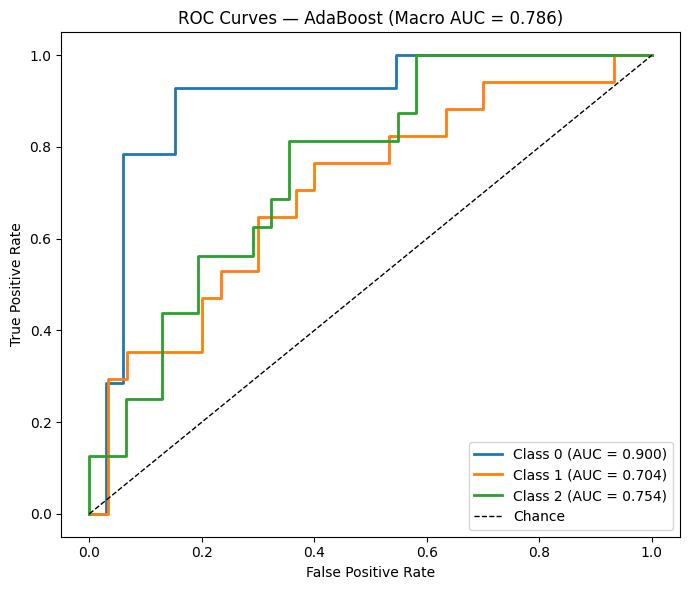

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Predicted probabilities and classes
y_prob = ada.predict_proba(X_test_used)   # (n_samples, n_classes)
classes = ada.classes_
n_classes = len(classes)

# ============ BINARY CASE ============
if n_classes == 2:
    # AUC (use prob of positive class)
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — AdaBoost")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# ============ MULTICLASS CASE ============
else:
    # One-vs-rest: binarize true labels
    y_test_bin = label_binarize(y_test, classes=classes)

    # Macro-average AUC
    auc_macro = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    # Plot ROC curve for each class
    plt.figure(figsize=(7, 6))
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, lw=2, label=f"Class {c} (AUC = {auc_i:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — AdaBoost (Macro AUC = {auc_macro:.3f})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

Hyperparameter tuning

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# define decision tree classifier
tree_clf = DecisionTreeClassifier()

# define AdaBoost classifier (new parameter name: estimator)
ada_clf = AdaBoostClassifier(estimator=tree_clf)

# define hyperparameters to tune (update key!)
params = {
    'estimator__max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200]
}

# create grid search object
grid_search = GridSearchCV(ada_clf, param_grid=params, cv=5, n_jobs=-1)

# fit grid search object to data
grid_search.fit(X_train, y_train)

# print best hyperparameters and corresponding accuracy score
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Accuracy Score: ", grid_search.best_score_)

Best Hyperparameters:  {'estimator__max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 200}
Best Accuracy Score:  0.5669985775248934


**MLP**

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

In [ ]:
# 1. Build the MLP Pipeline
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    # Standardizes all features to mean=0, std=1
    # MLP *requires* scaling to work properly
    # (otherwise gradients explode or vanish)

    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        # Two hidden layers:
        # Layer 1 → 128 neurons
        # Layer 2 → 64 neurons

        activation="relu",
        # Activation function inside hidden layers
        # ReLU helps fast learning and avoids vanishing gradients

        solver="adam",
        # Optimizer used to update weights (adaptive learning rate)

        alpha=1e-4,
        # L2 regularization term to reduce overfitting

        max_iter=500,
        # Maximum number of training iterations

        random_state=42,
        # Ensures reproducibility

        early_stopping=True,
        # Automatically stop training when model stops improving

        n_iter_no_change=20,
        # If validation score does not improve for 20 epochs → stop training
    ))
])

In [ ]:
# 2. Train the MLP
mlp_pipe.fit(X_train, y_train)
# Pipeline first scales the data, then trains the neural network

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(128, 64), max_iter=500,
                               n_iter_no_change=20, random_state=42))])

In [ ]:
# 3. Predict Test Labels
y_pred = mlp_pipe.predict(X_test)
# Uses trained network to predict the class for each test sample


# 4. Evaluate
acc = accuracy_score(y_test, y_pred)
# Calculate accuracy (correct predictions / total samples)

print(f"MLP Accuracy: {acc:.3f}")

print("Classification report:")
print(classification_report(y_test, y_pred, digits=3))
# Shows precision, recall, F1-score for each class (rounded to 3 decimals)

MLP Accuracy: 0.638
Classification report:
              precision    recall  f1-score   support

           0      0.588     0.714     0.645        14
           1      0.591     0.765     0.667        17
           2      0.875     0.438     0.583        16

    accuracy                          0.638        47
   macro avg      0.685     0.639     0.632        47
weighted avg      0.687     0.638     0.632        47



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import itertools

In [ ]:
# Predicted probabilities: shape (n_samples, n_classes)
y_prob = mlp_pipe.predict_proba(X_test)

# Class labels
classes = mlp_pipe.classes_
n_classes = len(classes)

# Convert y_test → One-vs-Rest binary matrix
y_test_bin = label_binarize(y_test, classes=classes)

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average AUC
auc_macro = roc_auc_score(
    y_test_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

print(f"Macro AUC: {auc_macro:.3f}")


Macro AUC: 0.686


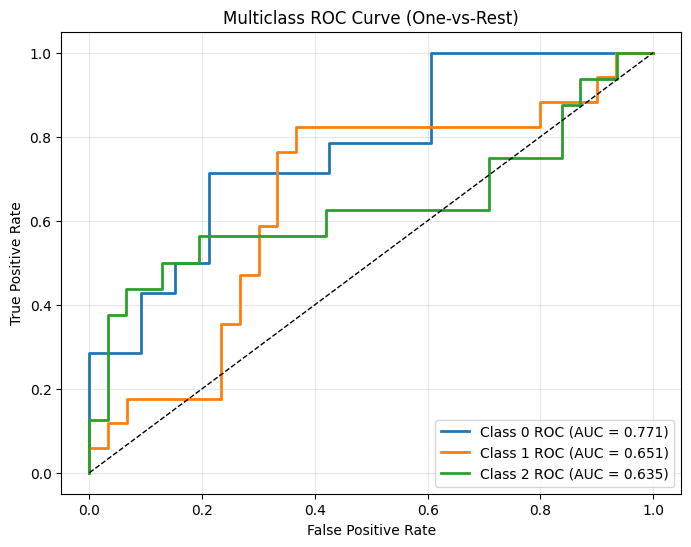

In [ ]:
plt.figure(figsize=(8, 6))

# Plot per-class ROC
for i, cls in enumerate(classes):
    plt.plot(
        fpr[i], tpr[i],
        lw=2,
        label=f"Class {cls} ROC (AUC = {roc_auc[i]:.3f})"
    )

# Plot diagonal
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
auc_table = {
    "Class": classes,
    "AUC": [roc_auc[i] for i in range(n_classes)]
}

import pandas as pd
auc_df = pd.DataFrame(auc_table)
auc_df


,Class,AUC
0,0,0.770563
1,1,0.650980
2,2,0.635081


Hyperparameter tuning

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# define multi-layer perceptron classifier
mlp_clf = MLPClassifier()

# define hyperparameters to tune
params = {'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (100,100)],
          'activation': ['relu', 'tanh', 'logistic'],
          'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
          'learning_rate': ['constant', 'adaptive']}

# create grid search object
grid_search = GridSearchCV(mlp_clf, param_grid=params, cv=5, n_jobs=-1)

# fit grid search object to data
grid_search.fit(X_train, y_train)

# print best hyperparameters and corresponding accuracy score
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Accuracy Score: ", grid_search.best_score_)

Best Hyperparameters:  {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'adaptive'}
Best Accuracy Score:  0.534850640113798


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Common setup for CNN and LSTM

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# X_train, X_test are (n_samples, n_features) from your CSV
X_train_arr = np.asarray(X_train, dtype="float32")
X_test_arr  = np.asarray(X_test, dtype="float32")

n_features = X_train_arr.shape[1]          # e.g. 837 or reduced
num_classes = len(np.unique(y_train))      # should be 3 for your case

print("X_train shape (before reshape):", X_train_arr.shape)
print("Number of features:", n_features)
print("Number of classes:", num_classes)

# Reshape to (samples, timesteps, channels) for 1D-CNN / LSTM
# Here: timesteps = n_features, channels = 1
X_train_seq = X_train_arr.reshape(-1, n_features, 1)
X_test_seq  = X_test_arr.reshape(-1, n_features, 1)

print("X_train shape (for sequence models):", X_train_seq.shape)
print("X_test shape (for sequence models):", X_test_seq.shape)

X_train shape (before reshape): (187, 164)
Number of features: 164
Number of classes: 3
X_train shape (for sequence models): (187, 164, 1)
X_test shape (for sequence models): (47, 164, 1)


**1D CNN**

In [12]:
# 1D-CNN model
cnn_model = models.Sequential([
    layers.Conv1D(filters=32, kernel_size=3, activation="relu", input_shape=(n_features, 1)),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  # multiclass output
])

cnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

cnn_model.summary()

# Train CNN
history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Evaluate on test
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nCNN Test Accuracy: {test_acc_cnn:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 162, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 81, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 79, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2496)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       159,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,339 (649.76 KB)

 Trainable params: 166,339 (649.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3821 - loss: 30.9173 - val_accuracy: 0.3617 - val_loss: 22.4145
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4309 - loss: 15.1396 - val_accuracy: 0.3191 - val_loss: 15.8300
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4390 - loss: 9.8621 - val_accuracy: 0.4043 - val_loss: 6.6609
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4505 - loss: 5.1413 - val_accuracy: 0.3404 - val_loss: 3.3296
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4115 - loss: 2.6997 - val_accuracy: 0.3830 - val_loss: 1.3542
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3942 - loss: 1.5585 - val_accuracy: 0.3617 - val_loss: 1.1800
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2923 - loss: 1.3444 - val_accuracy: 0.4468 - val_loss: 1.0749
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3812 - loss: 1.1123 - val_accuracy: 0.4043 - val_loss: 1.0

**LSTM**

In [ ]:
# LSTM model
lstm_model = models.Sequential([
    layers.LSTM(64, return_sequences=False, input_shape=(n_features, 1)),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

lstm_model.summary()

# Train LSTM
history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Evaluate on test
test_loss_lstm, test_acc_lstm = lstm_model.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nLSTM Test Accuracy: {test_acc_lstm:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,251 (83.01 KB)

 Trainable params: 21,251 (83.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.2956 - loss: 1.1047 - val_accuracy: 0.2979 - val_loss: 1.0948
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.3652 - loss: 1.0992 - val_accuracy: 0.3617 - val_loss: 1.0937
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.3599 - loss: 1.0993 - val_accuracy: 0.3830 - val_loss: 1.0936
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.4125 - loss: 1.0885 - val_accuracy: 0.3830 - val_loss: 1.0934
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.3554 - loss: 1.0947 - val_accuracy: 0.2979 - val_loss: 1.0935
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.4427 - loss: 1.0867 - val_accuracy: 0.3404 - val_loss: 1.0930
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.4048 - loss: 1.0793 - val_accuracy: 0.4043 - val_loss: 1.0901
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.3956 - loss: 1.0870 - val_accuracy: 0.4255 - val_loss: 1.088

**RNN**

In [ ]:
import numpy as np

X_train_arr = np.asarray(X_train, dtype="float32")
X_test_arr  = np.asarray(X_test, dtype="float32")

n_features  = X_train_arr.shape[1]          # e.g. 837 or reduced
num_classes = len(np.unique(y_train))       # probably 3

print("X_train shape (before reshape):", X_train_arr.shape)
print("Number of features:", n_features)
print("Number of classes:", num_classes)

# Reshape for RNN: (samples, timesteps, channels)
X_train_seq = X_train_arr.reshape(-1, n_features, 1)
X_test_seq  = X_test_arr.reshape(-1, n_features, 1)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape: ", X_test_seq.shape)

X_train shape (before reshape): (187, 164)
Number of features: 164
Number of classes: 3
X_train_seq shape: (187, 164, 1)
X_test_seq shape:  (47, 164, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

rnn_model = models.Sequential([
    # SimpleRNN layer
    layers.SimpleRNN(
        units=64,
        activation="tanh",
        input_shape=(n_features, 1)
    ),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  # multiclass output
])

rnn_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

rnn_model.summary()

# Train
history_rnn = rnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Evaluate
test_loss_rnn, test_acc_rnn = rnn_model.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nRNN Test Accuracy: {test_acc_rnn:.3f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,579 (33.51 KB)

 Trainable params: 8,579 (33.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.2944 - loss: 1.1561 - val_accuracy: 0.3404 - val_loss: 1.1215
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.3116 - loss: 1.1631 - val_accuracy: 0.4468 - val_loss: 1.0890
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.3437 - loss: 1.1227 - val_accuracy: 0.3830 - val_loss: 1.0893
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.3972 - loss: 1.1057 - val_accuracy: 0.4255 - val_loss: 1.0877
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.3925 - loss: 1.1030 - val_accuracy: 0.3404 - val_loss: 1.0944
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4360 - loss: 1.0869 - val_accuracy: 0.3617 - val_loss: 1.0911
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.3322 - loss: 1.1222 - val_accuracy: 0.3191 - val_loss: 1.0888
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4302 - loss: 1.0709 - val_accuracy: 0.3617 - val_loss: 1

**GRU**

In [ ]:
import numpy as np

# Convert to numpy
X_train_arr = np.asarray(X_train, dtype="float32")
X_test_arr  = np.asarray(X_test, dtype="float32")

# Number of features (columns)
n_features  = X_train_arr.shape[1]          # e.g. 837 or reduced
# Number of classes (e.g. 3: HC, PD, DD)
num_classes = len(np.unique(y_train))

print("X_train shape (before reshape):", X_train_arr.shape)
print("Number of features:", n_features)
print("Number of classes:", num_classes)

# Reshape to (samples, timesteps, channels)
# timesteps = n_features, channels = 1
X_train_seq = X_train_arr.reshape(-1, n_features, 1)
X_test_seq  = X_test_arr.reshape(-1, n_features, 1)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape: ", X_test_seq.shape)

X_train shape (before reshape): (187, 164)
Number of features: 164
Number of classes: 3
X_train_seq shape: (187, 164, 1)
X_test_seq shape:  (47, 164, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

gru_model = models.Sequential([
    # GRU layer
    layers.GRU(
        units=64,
        return_sequences=False,      # output only final state
        input_shape=(n_features, 1)
    ),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  # multiclass output
])

gru_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

gru_model.summary()

# Optional: early stopping to avoid overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train GRU
history_gru = gru_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss_gru, test_acc_gru = gru_model.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nGRU Test Accuracy: {test_acc_gru:.3f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,219 (67.26 KB)

 Trainable params: 17,219 (67.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 325ms/step - accuracy: 0.3701 - loss: 1.0954 - val_accuracy: 0.3191 - val_loss: 1.0963
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.3530 - loss: 1.0965 - val_accuracy: 0.3404 - val_loss: 1.0959
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.2590 - loss: 1.1049 - val_accuracy: 0.3191 - val_loss: 1.0944
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.3416 - loss: 1.0996 - val_accuracy: 0.4043 - val_loss: 1.0941
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.3567 - loss: 1.0950 - val_accuracy: 0.3830 - val_loss: 1.0939
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.4143 - loss: 1.0896 - val_accuracy: 0.3830 - val_loss: 1.0927
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.3465 - loss: 1.0939 - val_accuracy: 0.4043 - val_loss: 1.0923
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4265 - loss: 1.0890 - val_accuracy: 0.4043 - val_loss: